In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [2]:
table = pd.read_csv('./fifa-dataset/players_22.csv')

Matplotlib is building the font cache; this may take a moment.
/var/folders/q5/y7w8wy7n4f51qfry4bp9yks00000gn/T/ipykernel_68165/2136362999.py:4: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv('./fifa-dataset/players_22.csv')


In [4]:
table.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [3]:
table.shape

(19239, 110)

In [5]:
print(list(table.columns))

['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name', 'league_level', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined', 'club_contract_valid_until', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power

In [9]:
table['short_name']

0                  L. Messi
1            R. Lewandowski
2         Cristiano Ronaldo
3                 Neymar Jr
4              K. De Bruyne
                ...        
19234             Song Defu
19235             C. Porter
19236              N. Logue
19237             L. Rudden
19238    E. Lalchhanchhuaha
Name: short_name, Length: 19239, dtype: object

In [11]:
table['age']

0        34
1        32
2        36
3        29
4        30
         ..
19234    22
19235    19
19236    21
19237    19
19238    19
Name: age, Length: 19239, dtype: int64

In [12]:
table['age'].mean()

np.float64(25.210821768283175)

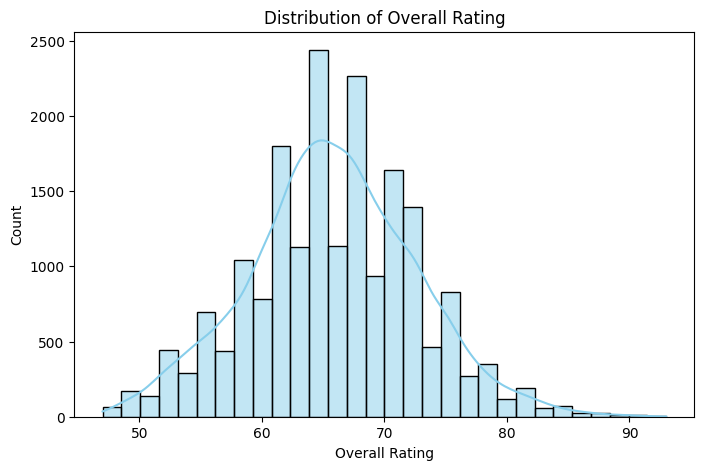

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(table['overall'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Count")
plt.show()

In [12]:
top_players = table[['short_name', 'overall', 'value_eur', 'wage_eur']].sort_values(by='overall', ascending=False).head(10)

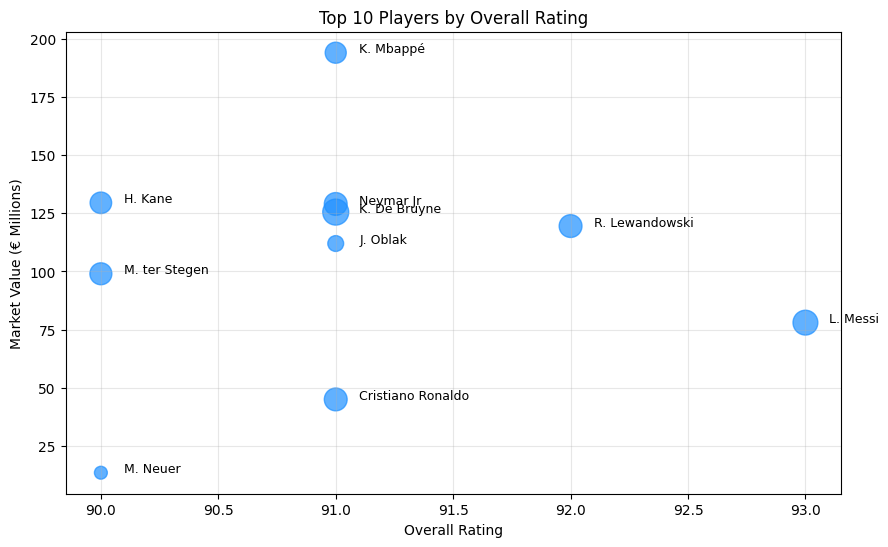

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(top_players['overall'], top_players['value_eur'] / 1e6, s=top_players['wage_eur'] / 1000, color='dodgerblue', alpha=0.7)

for i, name in enumerate(top_players['short_name']):
    plt.text(top_players['overall'].iloc[i] + 0.1, top_players['value_eur'].iloc[i] / 1e6, name, fontsize=9)

plt.xlabel("Overall Rating")
plt.ylabel("Market Value (€ Millions)")
plt.title("Top 10 Players by Overall Rating")
plt.grid(alpha=0.3)
plt.show()